In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid

import sys
sys.path.append("..")
from src.kde import df_bandwidth_selector, df_to_kde, get_rot_bandwidth_ck
from src.forecasting import cv
from src.utils import mark_repeated_columns

import warnings
from scipy.integrate import IntegrationWarning
import logging
import sys
import json

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=IntegrationWarning)

In [46]:
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df_returns = pd.read_excel(returns_path, index_col="time")
df_returns

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004
10:25:00,0.000364,-0.001532,0.000429,-0.000426,-0.000162,-0.000130,0.000060,0.000818,-0.000970,0.000670,...,-0.000871,-0.000559,0.001030,-0.000749,-0.001194,0.001338,0.000128,0.001279,-0.000162,-0.000651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16:40:00,-0.000169,0.000195,-0.000833,0.000137,0.000127,0.000062,0.000253,-0.003736,0.000405,0.000168,...,-0.000255,-0.000412,-0.000398,-0.000301,-0.000428,-0.000232,0.000473,-0.000521,0.000118,-0.000099
16:45:00,-0.000246,-0.000226,-0.000897,0.000536,0.001010,0.000047,-0.000063,0.002746,-0.000154,-0.000783,...,0.000344,0.000610,0.000224,-0.000353,0.000034,0.000054,-0.000519,0.000386,-0.000085,-0.000468
16:50:00,-0.000512,-0.000546,0.000553,0.000278,-0.000393,-0.000625,0.000141,-0.002952,0.002424,0.000244,...,0.000202,-0.000350,-0.000240,0.000239,-0.000314,-0.000175,0.000022,0.000298,0.000399,-0.000041


# Grid

In [206]:
from sklearn.model_selection import ParameterGrid

# 1. Define the parameter universes for each method
rot_grid = {
    "method": ["rot"],
    "kernel": ["gaussian", "epanechnikov"], #"tophat", "exponential", "linear", "cosine"],
    "sigma_robust": [True, False]
}

lcv_sklearn_grid = {
    "method": ["cross_validate_bandwidth"],
    "kernel": ["gaussian", "epanechnikov"], #"tophat", "exponential", "linear", "cosine"],
    "cv": [5]
}

lcv_t_grid = {
    "method": ["cross_validate_bandwidth"],
    "kernel": ["t-student"],
    "df": [df for df in range(2,6)],
    "cv": [5]#, "LOO"]
}

kernel_rules = np.unique([v for d in get_rot_bandwidth_ck().values() for v in d.keys()])
adaptive_grid = {
    "method": ["adaptive_bandwidth"],
    "kernel": ["gaussian", "epanechnikov"],
    # "h": kernel_rules
}
adaptive_grid_t = {
    "method": ["adaptive_bandwidth"],
    "kernel": ["t-student"],
    "df": [df for df in range(2,6)],
    # "h": kernel_rules
}

# 2. Combine grids and build the dictionary
density_param_grid = {}

for grid in [rot_grid, lcv_sklearn_grid, lcv_t_grid, adaptive_grid, adaptive_grid_t]:
    for params in ParameterGrid(grid):
        # Create a unique key based on the parameters
        # e.g., "rot_gaussian_robust_True" or "lcv_t-student_df_3"
        key_parts = [params["method"].replace("_","")]
        if "kernel" in params: key_parts.append(params["kernel"])
        if "df" in params: key_parts.append(f"df={params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        # ADD THESE TWO LINES:
        if "alpha" in params: key_parts.append(f"a{params['alpha']}")
        if "h" in params: key_parts.append(f"h{params['h']}") # Distinguish different pilot h values
        
        name = "_".join(key_parts).replace(".", "") # Remove dots for cleaner keys
        density_param_grid[name] = params

In [207]:
density_param_grid

{'rot_gaussian_robust': {'kernel': 'gaussian',
  'method': 'rot',
  'sigma_robust': True},
 'rot_gaussian': {'kernel': 'gaussian',
  'method': 'rot',
  'sigma_robust': False},
 'rot_epanechnikov_robust': {'kernel': 'epanechnikov',
  'method': 'rot',
  'sigma_robust': True},
 'rot_epanechnikov': {'kernel': 'epanechnikov',
  'method': 'rot',
  'sigma_robust': False},
 'crossvalidatebandwidth_gaussian': {'cv': 5,
  'kernel': 'gaussian',
  'method': 'cross_validate_bandwidth'},
 'crossvalidatebandwidth_epanechnikov': {'cv': 5,
  'kernel': 'epanechnikov',
  'method': 'cross_validate_bandwidth'},
 'crossvalidatebandwidth_t-student_df=2': {'cv': 5,
  'df': 2,
  'kernel': 't-student',
  'method': 'cross_validate_bandwidth'},
 'crossvalidatebandwidth_t-student_df=3': {'cv': 5,
  'df': 3,
  'kernel': 't-student',
  'method': 'cross_validate_bandwidth'},
 'crossvalidatebandwidth_t-student_df=4': {'cv': 5,
  'df': 4,
  'kernel': 't-student',
  'method': 'cross_validate_bandwidth'},
 'crossvalidate

In [ ]:
# corresp_names = dict(zip(results_df.kde_params.unique().tolist(), density_param_grid))
# results_df["kde_params"] = results_df["kde_params"].replace(corresp_names)

In [48]:
for model, params in density_param_grid.items():
    if "cross" in model:
        print(model)

crossvalidatebandwidth_gaussian
crossvalidatebandwidth_epanechnikov
crossvalidatebandwidth_tstudent_df2
crossvalidatebandwidth_tstudent_df3
crossvalidatebandwidth_tstudent_df4
crossvalidatebandwidth_tstudent_df5


# KDE results for grid

In [ ]:
results = {}
for name, params in density_param_grid.items():
    print(f"Processing configuration: {name}")
    
    # 1. Generate Bandwidths
    # We pass the whole params dict as kwargs to handle 'sigma_robust', 'df', etc.
    df_h = df_bandwidth_selector(df_returns, **params)
    
    # 2. Generate KDE Grids and Densities
    # Note: 'method' and 'sigma_robust' aren't used by KDE class, 
    # so we filter to pass only kernel and specific params like 'df'
    kde_params = {k: v for k, v in params.items() if k in ['kernel', 'df']}
    
    df_grids, df_densities = df_to_kde(
        X=df_returns, 
        h=df_h, 
        **kde_params
    )

    results[name]= {
        "df_h":         df_h,
        "df_grids":     df_grids,
        "df_densities": df_densities
    }
    
    # 3. Plotting
    # plt.figure(figsize=(15,5))
    # plt.title(f"KDE: {name}")
    # for col_name in df_densities.columns:
    #     plt.plot(df_grids.loc[:,col_name], df_densities.loc[:,col_name])
    # plt.show()

<Axes: >

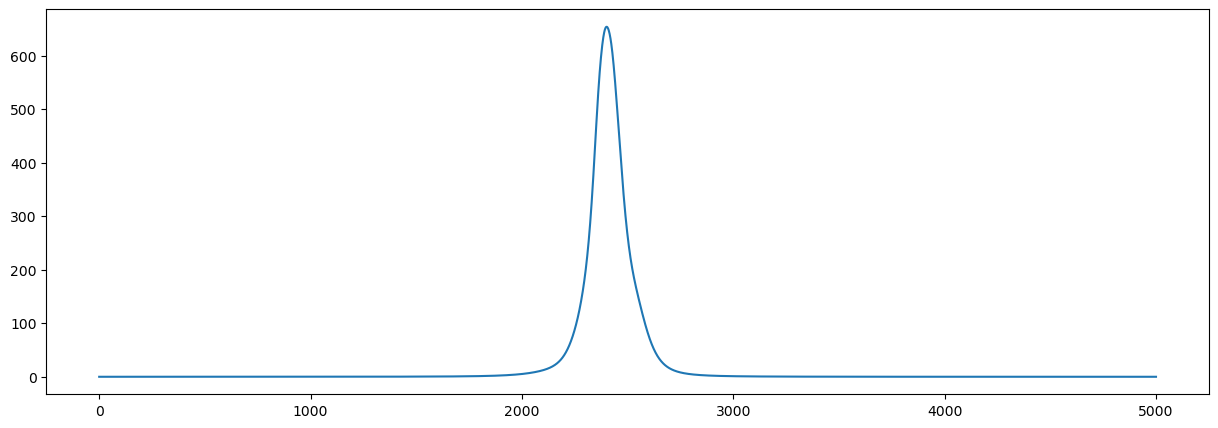

In [54]:
results['adaptivebandwidth_tstudent_df2']["df_densities"].iloc[:,10].plot(legend=False, figsize=(15,5))

# Full cross validation

## Parameters

In [4]:
## Density treatment
normalize_options = [True, False]
print("Further processing for KDE:", len(normalize_options))

## dFPC estimation
dimensions_list = range(2,7)
print("Dimensions for dFPC:", len(dimensions_list))

## Total parameters
total_params = len(density_param_grid) * len(normalize_options) * len(dimensions_list)
print("Total parameters to cross-validate:", total_params)

Further processing for KDE: 2
Dimensions for dFPC: 5
Total parameters to cross-validate: 160


## Run

In [5]:
# 1. Setup Logger
logger = logging.getLogger("Density_Estimation")
logger.setLevel(logging.DEBUG)

# 2. Setup File Handler
file_handler = logging.FileHandler('../logs/cross_validation_20260225.log')
file_handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger.addHandler(file_handler)

# 3. CAPTURE WARNINGS: This handles "Forecast with mean" style warnings
logging.captureWarnings(True)

In [6]:
KdFPC_kwargs = {
    "lag_max": 5,
    "alpha": 0.10,
    "du": 0.05,
    "B": 1000,
    "p": 5,
    # "u": df_lqds_support,
    "select_ncomp": False,
    # "dimension": 2
}

# logger.info("\nInitiating cross validation...")
i=1
j=1
params_dict = {}
records = []
logger.info("\nInitiating cross validation...")
for normalize in normalize_options:
    for name, params in density_param_grid.items():
        df_h = df_bandwidth_selector(df_returns, **params)
        kde_params = {k: v for k, v in params.items() if k in ['kernel', 'df']}
        df_support, df_densities = df_to_kde(
            X=df_returns, 
            h=df_h, 
            normalize_densities=normalize,
            **kde_params
        )
        
        for d in dimensions_list:
            # print(f"({i}/{total_params}) | Normalize = {normalize} | {params}")
            logger.info(f"Progress: ({i}/{total_params}) | Normalize: {normalize} | KDE model: {name} | Dimensions: {d}")
            
            i += 1
            # print(f"\tEstimation using {d} dimensions.")
            logger.info(f"\tEstimation using {d} dimensions.")
            KdFPC_kwargs.update(
                {"dimension": d}
                )
            
            try:
                cv_measures = cv(df_densities, df_support, KdFPC_kwargs = KdFPC_kwargs, var_lags=d, initial_window=100)
            except Exception as e:
                # print(f"\t ERROR for d={d} and {params} : {e}")
                logger.exception(f"\t ERROR for d={d} and {params} : {e}")
                continue
            for m in cv_measures:
                if params["kernel"] == 't_student':
                    kernel_desc = params["kernel"] + "_df_" + str(params["df"])
                else:
                    kernel_desc = params["kernel"]
                record = {
                    # density
                    "normalized_density": normalize,
                    
                    # parameters
                    "kde_params": name,
                    # "kernel": kernel_desc,
                    # "bandwidth": params["bandwidth"],
                    # "adaptive": params["adaptive"],

                    # CV info
                    "fold": m["fold"]+1,
                    "method": m["method"],

                    # metrics
                    "dFPC_dimensions":   d,
                    "KLD": float(m["KLD"]),
                    "JSD": float(m["JSD"]),
                    "L_1": float(m["L_1"]),
                    "L_2": float(m["L_2"]),
                    "L_INFTY": float(m["L_INFTY"]),
                }

                records.append(record)

        with open(f'../data/interim/cv/20260225/cv_{j}.json', 'w', encoding='utf-8') as f:
            json.dump(records, f, indent=4, ensure_ascii=False)
        
        j += 1

logging.info("Finished cross validation...\n")
            
results_df = pd.DataFrame(records)

		>>> cv 1/147
		>>> cv 2/147
		>>> cv 3/147
		>>> cv 4/147
		>>> cv 5/147
		>>> cv 6/147
		>>> cv 7/147
		>>> cv 8/147
		>>> cv 9/147
		>>> cv 10/147
		>>> cv 11/147
		>>> cv 12/147
		>>> cv 13/147
		>>> cv 14/147
		>>> cv 15/147
		>>> cv 16/147
		>>> cv 17/147
		>>> cv 18/147
		>>> cv 19/147
		>>> cv 20/147
		>>> cv 21/147
		>>> cv 22/147
		>>> cv 23/147
		>>> cv 24/147
		>>> cv 25/147
		>>> cv 26/147
		>>> cv 27/147
		>>> cv 28/147
		>>> cv 29/147
		>>> cv 30/147
		>>> cv 31/147
		>>> cv 32/147
		>>> cv 33/147
		>>> cv 34/147
		>>> cv 35/147
		>>> cv 36/147
		>>> cv 37/147
		>>> cv 38/147
		>>> cv 39/147
		>>> cv 40/147
		>>> cv 41/147
		>>> cv 42/147
		>>> cv 43/147
		>>> cv 44/147
		>>> cv 45/147
		>>> cv 46/147
		>>> cv 47/147
		>>> cv 48/147
		>>> cv 49/147
		>>> cv 50/147
		>>> cv 51/147
		>>> cv 52/147
		>>> cv 53/147
		>>> cv 54/147
		>>> cv 55/147
		>>> cv 56/147
		>>> cv 57/147
		>>> cv 58/147
		>>> cv 59/147
		>>> cv 60/147
		>>> cv 61/147
		>>> cv 62/147
		>>> cv 63/147
	

## Results

In [268]:
results_df = pd.read_json("../data/interim/cv/20260225/cv_32.json")

In [269]:
# Rename variables and treat fields
bandwidth_map = {
    # ROT Methods (Method_Kernel_Extra)
    'rot_gaussian_robust':      'rot_gaussian_robust',
    'rot_gaussian':             'rot_gaussian',
    'rot_epanechnikov_robust':  'rot_epanechnikov_robust',
    'rot_epanechnikov':         'rot_epanechnikov',

    # Cross Validate Methods (Underscores removed from method name)
    'cross_validate_bandwidth_gaussian':     'cross-validation_gaussian',
    'cross_validate_bandwidth_tstudent_df2': 'cross-validation_t-student | df=2',
    'cross_validate_bandwidth_tstudent_df3': 'cross-validation_t-student | df=3',
    'cross_validate_bandwidth_tstudent_df4': 'cross-validation_t-student | df=4',
    'cross_validate_bandwidth_tstudent_df5': 'cross-validation_t-student | df=5',

    # Adaptive Methods (Underscores removed from method name)
    'adaptive_bandwidth_gaussian':     'adaptive_gaussian',
    'adaptive_bandwidth_epanechnikov': 'adaptive_epanechnikov',
    'adaptive_bandwidth_tstudent_df2': 'adaptive_t-student | df=2',
    'adaptive_bandwidth_tstudent_df3': 'adaptive_t-student | df=3',
    'adaptive_bandwidth_tstudent_df4': 'adaptive_t-student | df=4',
    'adaptive_bandwidth_tstudent_df5': 'adaptive_t-student | df=5'
}

results_df["kde_params"] = results_df["kde_params"].replace(bandwidth_map)

detail = results_df.kde_params.str.split("_", expand=True)

results_df[["bandwidth", "kernel", "robust_std"]] = detail
results_df["robust_std"] = results_df["robust_std"].fillna('False')

results_df = results_df[['normalized_density', 'kde_params', 'bandwidth', 'kernel', 'robust_std', 'dFPC_dimensions', 'fold', 'KLD', 'JSD',
       'L_1', 'L_2', 'L_INFTY', ]]

results_df.head()

,normalized_density,kde_params,bandwidth,kernel,robust_std,dFPC_dimensions,fold,KLD,JSD,L_1,L_2,L_INFTY
0,True,rot_gaussian_robust,rot,gaussian,robust,2,1,0.051251,0.002685,15222.842474,911.815994,92.487038
1,True,rot_gaussian_robust,rot,gaussian,robust,2,2,0.017890,0.000801,10501.183031,740.873613,80.832096
2,True,rot_gaussian_robust,rot,gaussian,robust,2,3,0.011463,0.000354,6667.423117,449.015354,58.640618
3,True,rot_gaussian_robust,rot,gaussian,robust,2,4,0.032898,0.001005,11219.581091,682.585770,80.803197
4,True,rot_gaussian_robust,rot,gaussian,robust,2,5,0.080247,0.006256,30851.789739,2357.599314,368.999369


In [271]:
# results_df.to_excel("../data/processed/cv/20260225/cv_density_forecasting_20260224.xlsx", index=False)
results_df = pd.read_excel("../data/processed/cv/20260225/cv_density_forecasting_20260224.xlsx")
results_df.head()

,normalized_density,kde_params,bandwidth,kernel,robust_std,dFPC_dimensions,fold,KLD,JSD,L_1,L_2,L_INFTY
0,True,rot_gaussian_robust,rot,gaussian,robust,2,1,0.051251,0.002685,15222.842474,911.815994,92.487038
1,True,rot_gaussian_robust,rot,gaussian,robust,2,2,0.017890,0.000801,10501.183031,740.873613,80.832096
2,True,rot_gaussian_robust,rot,gaussian,robust,2,3,0.011463,0.000354,6667.423117,449.015354,58.640618
3,True,rot_gaussian_robust,rot,gaussian,robust,2,4,0.032898,0.001005,11219.581091,682.585770,80.803197
4,True,rot_gaussian_robust,rot,gaussian,robust,2,5,0.080247,0.006256,30851.789739,2357.599314,368.999369


In [270]:
metrics = ["KLD", "JSD", "L_1", "L_2", "L_INFTY"]

mean_df = (
    results_df
    .groupby(['normalized_density', 'bandwidth', 'kernel', 'robust_std', 'dFPC_dimensions'])[metrics]
    .mean()
    .reset_index()
).sort_values(by = "KLD", ascending=True)

# mean_df.sort_values(by="KLD", ascending=True, inplace=True)

mean_df

,normalized_density,bandwidth,kernel,robust_std,dFPC_dimensions,KLD,JSD,L_1,L_2,L_INFTY
86,True,adaptive,t-student | df=2,False,3,0.029658,0.002028,14315.413663,972.716787,128.029798
85,True,adaptive,t-student | df=2,False,2,0.029878,0.002037,14342.359824,977.563659,128.803563
87,True,adaptive,t-student | df=2,False,4,0.031235,0.002134,14611.725834,994.001258,131.185273
91,True,adaptive,t-student | df=3,False,3,0.031490,0.002138,14569.360597,1004.970626,132.180075
90,True,adaptive,t-student | df=3,False,2,0.031762,0.002150,14610.777551,1010.884809,133.105191
...,...,...,...,...,...,...,...,...,...,...
71,False,rot,gaussian,robust,3,1.534767,0.046940,49140.525383,7325.217819,4151.874428
69,False,rot,gaussian,False,6,1.552829,0.087342,72529.602666,11525.118992,6096.889245
72,False,rot,gaussian,robust,4,2.046760,0.081052,69019.117644,12403.970011,7465.802245
74,False,rot,gaussian,robust,6,2.786717,0.122851,92991.110799,17997.033561,10983.658838


In [255]:
mean_df.to_excel("../data/processed/cv/20260225/cv_density_forecasting_20260224_summary.xlsx", index=False)

In [91]:
# for m in metrics:
#     best_value = mean_df[m].min()
#     mean_df[f"win_{m}"] = mean_df[m] == best_value

# win_cols = [f"win_{m}" for m in metrics]

# mean_df["n_wins"] = mean_df[win_cols].sum(axis=1)

# best_overall = mean_df.sort_values(["n_wins","KLD"], ascending=[False, True])

# print("Best overall method:\n", best_overall.iloc[0])

In [273]:
# Best non-normalized models
mean_df[mean_df.normalized_density==False].sort_values(by="KLD").head(10)

,normalized_density,bandwidth,kernel,robust_std,dFPC_dimensions,KLD,JSD,L_1,L_2,L_INFTY
11,False,adaptive,t-student | df=2,False,3,0.066998,0.004499,21526.210911,1137.190822,134.942427
10,False,adaptive,t-student | df=2,False,2,0.067625,0.004541,21488.984149,1140.798440,135.413807
12,False,adaptive,t-student | df=2,False,4,0.070004,0.004703,22025.269920,1170.150676,139.793859
13,False,adaptive,t-student | df=2,False,5,0.076433,0.005083,22751.879761,1212.853624,145.826924
14,False,adaptive,t-student | df=2,False,6,0.082034,0.005426,23530.961123,1251.759894,150.848522
16,False,adaptive,t-student | df=3,False,3,0.090721,0.005227,10694.190473,814.054628,142.733953
15,False,adaptive,t-student | df=3,False,2,0.092229,0.005283,9759.604753,782.695645,142.876079
17,False,adaptive,t-student | df=3,False,4,0.094191,0.005427,11558.872458,859.774891,148.048620
26,False,adaptive,t-student | df=5,False,3,0.098918,0.005213,23878.742302,1283.703333,149.290715
25,False,adaptive,t-student | df=5,False,2,0.099556,0.005203,24065.672505,1289.217251,149.200195


In [272]:
mean_df.head(3).to_clipboard()

In [238]:
N = 10
pd.concat([mean_df[mean_df.normalized_density==True].head(N), mean_df[mean_df.normalized_density==False].head(N)])

,normalized_density,bandwidth,kernel,extra,dFPC_dimensions,KLD,JSD,L_1,L_2,L_INFTY
81,True,adaptive,t-student | df=2,none,3,0.029658,0.002028,14315.413663,972.716787,128.029798
80,True,adaptive,t-student | df=2,none,2,0.029878,0.002037,14342.359824,977.563659,128.803563
82,True,adaptive,t-student | df=2,none,4,0.031235,0.002134,14611.725834,994.001258,131.185273
86,True,adaptive,t-student | df=3,none,3,0.031490,0.002138,14569.360597,1004.970626,132.180075
85,True,adaptive,t-student | df=3,none,2,0.031762,0.002150,14610.777551,1010.884809,133.105191
83,True,adaptive,t-student | df=2,none,5,0.032071,0.002187,15001.847432,1021.943672,135.615319
91,True,adaptive,t-student | df=4,none,3,0.032526,0.002203,14720.721602,1024.507290,134.814993
90,True,adaptive,t-student | df=4,none,2,0.032796,0.002220,14784.191831,1031.883404,135.986241
96,True,adaptive,t-student | df=5,none,3,0.033037,0.002237,14793.375444,1036.294776,136.414075
87,True,adaptive,t-student | df=3,none,4,0.033284,0.002256,14936.473611,1031.840120,136.028733
